# Devoir – Algorithme N.S. 
> **Professeur :** Dr. Evens **TOUSSAINT**

> **Étudiant   :** 
- Jameson **PIERREVILLE**
- Steve  **CALIXTE**
- Fabrice **HERARD**

![Alt text](image/im1.jpeg)

[Voir le repertoire GITHUB](https://github.com/Poincare008/Wine-Exploratory-Study.git)

## Étude Exploratoire du Jeu de Données Wine

Le présent travail est réalisé dans le cadre du cours de Machine Learning Non
 Supervisé. Il s'inscrit dans une démarche d'étude exploratoire appliquée à un
 jeu de données réel, le Wine Dataset, disponible directement via la
 bibliothèque scikit-learn. 

L'objectif principal de ce travail consiste a mobiliser plusieurs méthodes
d'apprentissage non supervisé (Kmeans, DBSCAN, Clustering Agglomeratif, ACP
Isolation forest) afin de découvrir la structure cachée des données, 
sans avoir recours à desétiquettes prédéfinies. 

L'apprentissage non supervisé occupe une placecentrale en science des données.
Contrairement à l'apprentissage supervisé,il ne s'appuie sur aucune variable
cible pour guider l'analyse, il cherche plutôt à faire émerger des patterns
naturels directement depuis les données brutes, ce qui en fait un outil particulièrement puissant pour l'exploration, la segmentation et la détection d'anomalies. C'est précisément dans cette logique
que s'inscrit notre démarche.

Le jeu de données Wine Dataset est issu d'analyses chimiques réalisées sur des
vins produits dans une même région d'Italie, provenant de trois cultivars
distincts. Il comprend 78 observations et 13 variables numériques.

## Démarche adoptée
Notre analyse suivra une progression logique et rigoureuse :
1)	Chargement et exploration initiale des données
2)	Prétraitement et standardisation des variables
3)	Application et comparaison des méthodes de clustering
4)	Réduction de dimension par ACP et visualisation
5)	Détection d'anomalies par Isolation Forest
6)	Synthèse comparative et conclusion argumentée
Chaque étape est accompagnée d'une interprétation des résultats, afin de dégager des conclusions pertinentes sur la structure du jeu de données Wine.

## Outil collaboratif
Comme outil collaboratif, nous avons utilise [GitHub](https://github.com/Poincare008/Wine-Exploratory-Study.git), qui nous a permis d’héberger notre projet, mais aussi de collaborer efficacement et en temps réel sur la production et la révision du code.

## Chargement et Presentation des donnees

In [30]:
# importation des bibliotheques necessaires pour la realisation de ce travail
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings 
warnings.filterwarnings("ignore")
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

In [17]:
# chargement des donnees 
wine = load_wine()

#Creation d'un DtaFrame pour faciliter l'exploration des donnees
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
# etiquettes relles (cultivars 0, 1 ou 2) 
print(" apercu des donnees :")
print(" nombre d'observations : ", df.shape[0]) 
print(" nombre de variables : ", df.shape[1] - 1, " + 1 colonne cible")
print(" classes (cultivars) : ", np.unique(wine.target), " - ", np.bincount(wine.target), " observations chacune")
print()
df.head()


 apercu des donnees :
 nombre d'observations :  178
 nombre de variables :  13  + 1 colonne cible
 classes (cultivars) :  [0 1 2]  -  [59 71 48]  observations chacune



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
# staistiques decscriptives 
print (" statistique descritive ")
df.drop (columns= "target").describe().round(2)

 statistique descritive 


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [19]:
# verification des valeurs manquantes
missing= df.isnull().sum()
print("Valeurs manquantes par variable :")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante détectée")

Valeurs manquantes par variable :
Aucune valeur manquante détectée


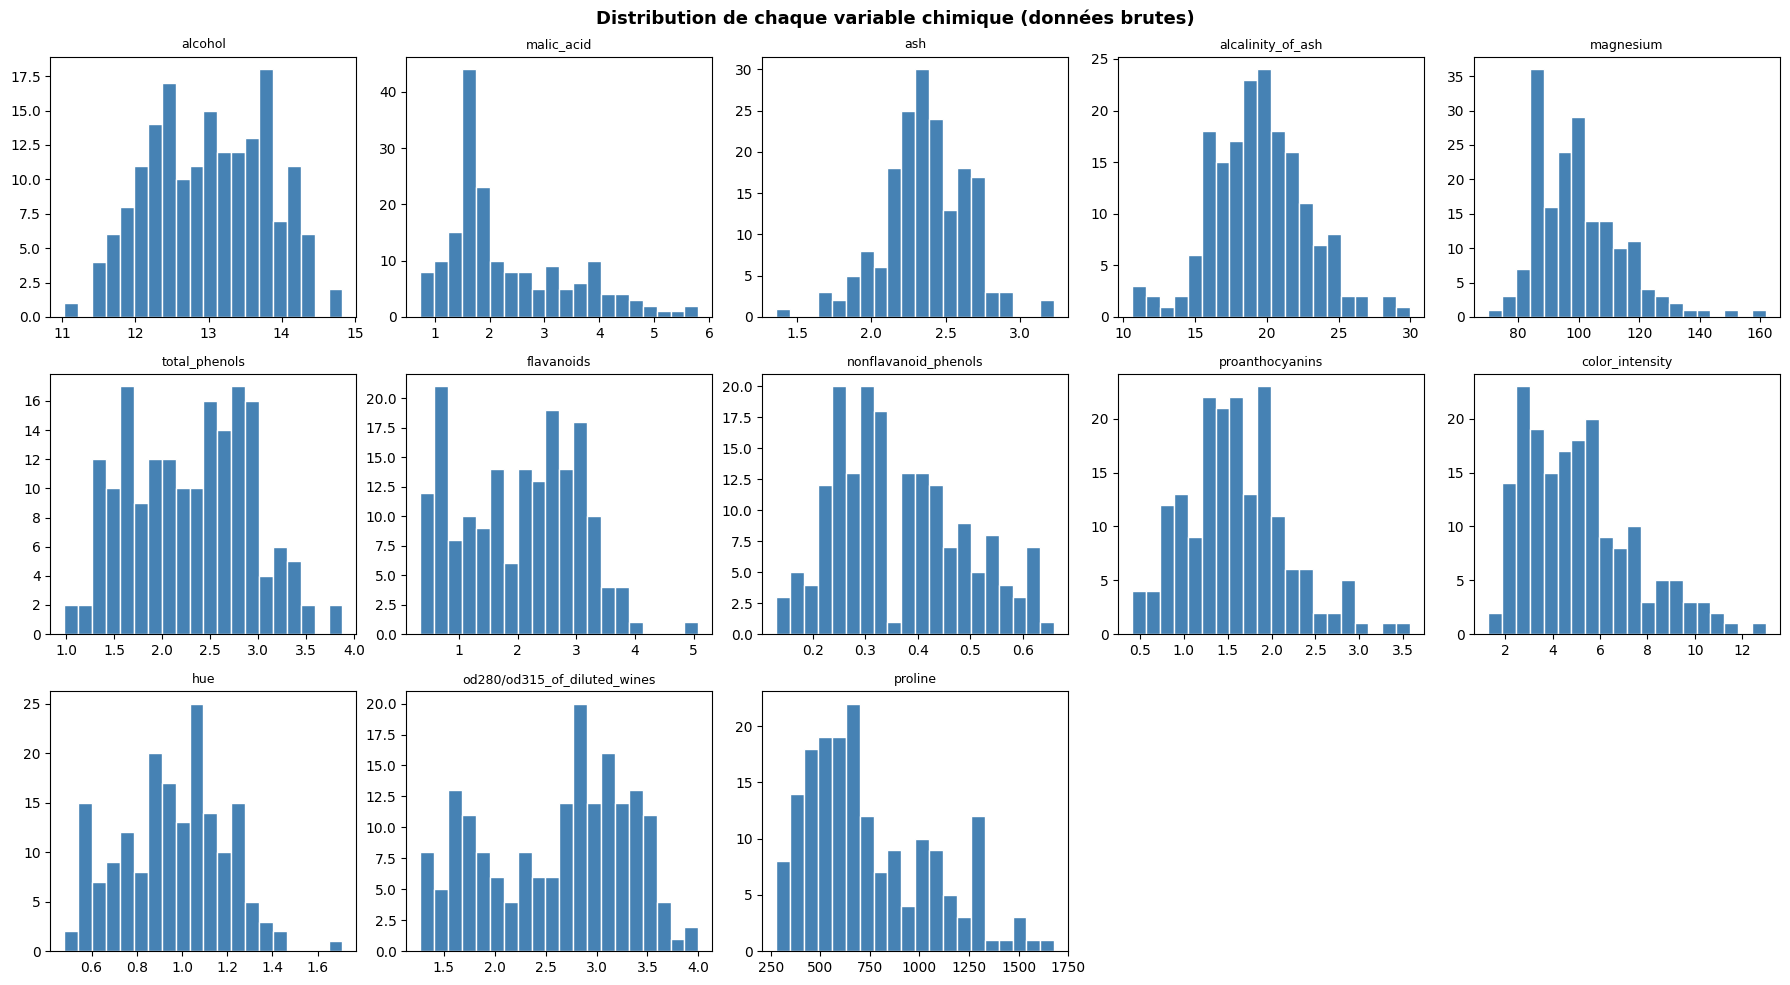

In [21]:
# visualisation des distribution par variable
features = wine.feature_names
X_raw = df[features]

fig, axes = plt.subplots(3,5,figsize= (18,10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X_raw[col], bins=20, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# masquer les cases inutilisees
for j in range (len(features), len (axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribution de chaque variable chimique (données brutes)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()    

### Analyse: 



Le jeu de donnees wine contient 178 observations decrites par 13 variables numeriques continues , sans aucune valeur manquante.
Les trois cultivars sont representes respectivement par 59 71 et 48 observations, cette  distribution legement desequlibree meis  acceptable.

Les histogrammes revelent des echelles tres differentes entre les variables :
la paroline varie entre 278 et 1680 , tandis que lws Nonflanoid phenols oscillent entre 0.13 et 0.66
cette disparitee rend la standardisation indispensable avant d'apliquer des algorithmes bases sur les distances.


## Pretraitement des donnees


In [22]:
# standardisation ( moyenne 0, ecart-type 1)
# on travaille uniquement sur les 13  variables ( sans la colonne "target")
X= df[features].values

scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

# verifications: moyenne ≈ 0, ecart-type ≈ 1

print("Après standardisation :")
print(f"  Moyenne globale  : {X_scaled.mean():.4f}")
print(f"  Écart-type global: {X_scaled.std():.4f}")


Après standardisation :
  Moyenne globale  : -0.0000
  Écart-type global: 1.0000


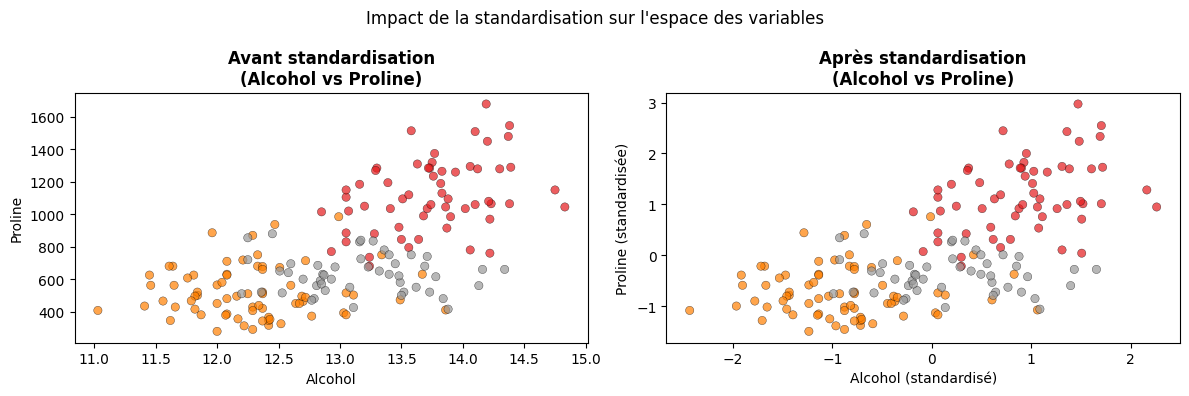

In [23]:
# comparaison avant ? apres standardisation sur 2 variables 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# avant 
axes[0].scatter(X[:, 0], X[:, 12], c=df['target'], cmap='Set1', alpha=0.7, edgecolors='k', linewidths=0.3)
axes[0].set_title("Avant standardisation\n(Alcohol vs Proline)", fontweight='bold')
axes[0].set_xlabel("Alcohol"); axes[0].set_ylabel("Proline")

# apres 
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 12], c=df['target'], cmap='Set1', alpha=0.7, edgecolors='k', linewidths=0.3)
axes[1].set_title("Après standardisation\n(Alcohol vs Proline)", fontweight='bold')
axes[1].set_xlabel("Alcohol (standardisé)"); axes[1].set_ylabel("Proline (standardisée)")

plt.suptitle("Impact de la standardisation sur l'espace des variables", fontsize=12)
plt.tight_layout()
plt.show()

### Pourquoi standardiser?
Les algorithmes Kmeans, DBSCAN et clustering aglomeratif reposent tous sur le calcul de distance entre observation ( distance euclidienne par defaut). Sans standardisation , une variable comme la proline dominerait artificiellement le calcul par rapport aux Nonflavonoid Phenols par rapport aux Nonflavonoid phenols (valeurs <1 ). le modele ignorait alors des variations pourtant signifiocatives dans les petites variables.

La standardisation ramene chaque variable a une moyenne de 0 et un ecart-type de 1, ce qui garantit que toutes les variables contribuent equitablement au calcul des distances. C'est une etape incourtournable pour obtenir des groupes coherents.

## Application de K-Means

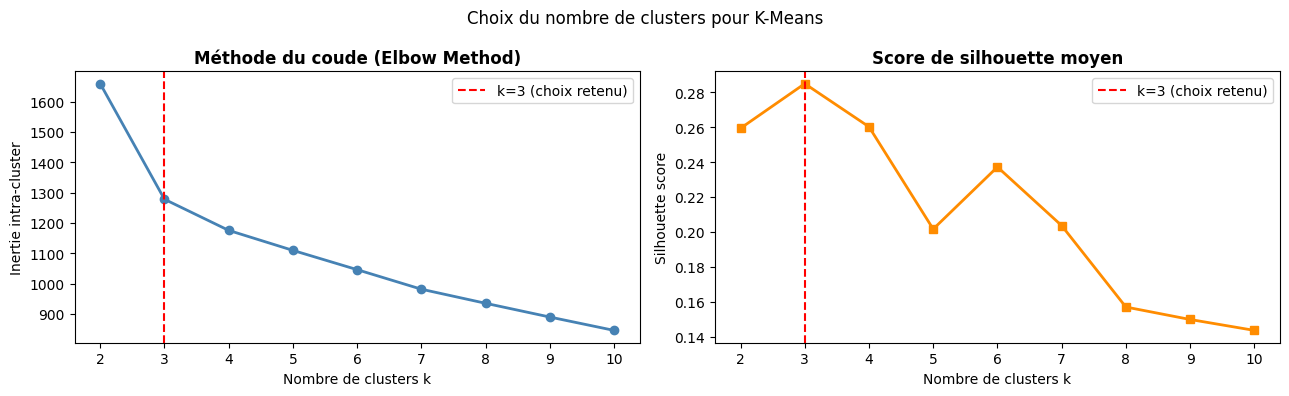

Scores de silhouette par k :
  k=2 → silhouette = 0.2593
  k=3 → silhouette = 0.2849
  k=4 → silhouette = 0.2602
  k=5 → silhouette = 0.2016
  k=6 → silhouette = 0.2372
  k=7 → silhouette = 0.2036
  k=8 → silhouette = 0.1570
  k=9 → silhouette = 0.1499
  k=10 → silhouette = 0.1436


In [24]:
# On fait le choix du nombre de clusters avec deux approches a savoir la méthode du coude (Elbow) + Score de silhouette ---
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbe du coude : on regarde où l'inertie diminue fortement
axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='k=3 (choix retenu)')
axes[0].set_title("Méthode du coude (Elbow Method)", fontweight='bold')
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie intra-cluster")
axes[0].legend()

# Score de silhouette : plus c'est eleve, mieux les clusters sont separes
axes[1].plot(K_range, silhouettes, 's-', color='darkorange', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='k=3 (choix retenu)')
axes[1].set_title("Score de silhouette moyen", fontweight='bold')
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.suptitle("Choix du nombre de clusters pour K-Means", fontsize=12)
plt.tight_layout()
plt.show()

print("Scores de silhouette par k :")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k} → silhouette = {s:.4f}")

In [25]:
# --- Entraînement final avec k=3 ---
# Dans cette partie on fixe le nombre de clusters a 3,car c'est celui 
# semblait le plus pertinent
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("=== Résultats K-Means (k=3) ===")
# on note aussi que L'inertie mesure la compacite des ckusters
# donc, plus c'est petit, mieux c'est)
print(f"Inertie finale     : {kmeans.inertia_:.2f}")
# Aussi, le score de silhouette indique la qualite de separation 
# entre les clusters
print(f"Score de silhouette: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"ARI vs vérité terrain : {adjusted_rand_score(df['target'], kmeans_labels):.4f}")
print()

# on affiche combien d'observations tombent dans les clusters
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u} : {c} observations")

=== Résultats K-Means (k=3) ===
Inertie finale     : 1277.93
Score de silhouette: 0.2849
ARI vs vérité terrain : 0.8975

  Cluster 0 : 65 observations
  Cluster 1 : 51 observations
  Cluster 2 : 62 observations


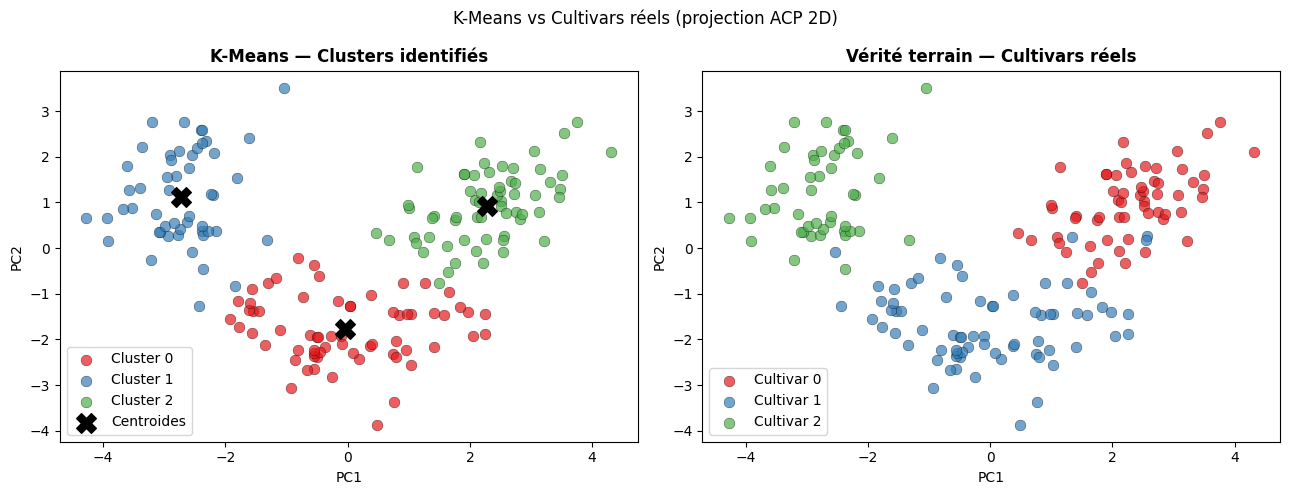

In [26]:
# Visualisation des clusters K-Means dans l'espace PCA (2D) 
# On reduit les donnees a 2 dimensions avec l'ACP pour pouvoir
# les representer facilement
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#e41a1c', '#377eb8', '#4daf4a']

# Visualisation des clusters trouves par K-Means
# Chaque clusters correspond a un cluster identifie par l'algorithme
for c in np.unique(kmeans_labels):
    mask = kmeans_labels == c
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=colors[c], label=f'Cluster {c}',
                    alpha=0.7, edgecolors='k', linewidths=0.3, s=60)
# On ajoute des centroides pour montrer le centre de chaque cluster
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[0].set_title("K-Means — Clusters identifiés", fontweight='bold')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

# On presente la visualisation de la vérité terrain
# ici, on compare les clusters calcules avec les classes reelles
for c in np.unique(df['target']):
    mask = df['target'] == c
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=colors[c], label=f'Cultivar {c}',
                    alpha=0.7, edgecolors='k', linewidths=0.3, s=60)
axes[1].set_title("Vérité terrain — Cultivars réels", fontweight='bold')
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend()

plt.suptitle("K-Means vs Cultivars réels (projection ACP 2D)", fontsize=12)
plt.tight_layout()
plt.show()

**Analyse K-Means :**

Les deux courbes qu'on a tracees pointent vers la meme reponse a savoir 3 groupes. La courbe du coude fait un virage net a k = 3, et le score de silhouette atteint son pic exactement la. C'est aussi le nombre de cultivars dans le dataset, coherent avec la nature du jeu de donnnes. Une fois l'algorithme tourne avec k=3, les groupes chimiques identifiés correspondent bien aux variétés botaniques. La projection ACP confirme visuellement la separation nette des trois clusters

On remarque quelques limites tout de meme a savoir K-Means suppose des sphérique et de taille équilibrée, et reste sensible aux valeurs initiales (atténué ici par n_init=10).

## 4. Application de DBSCAN

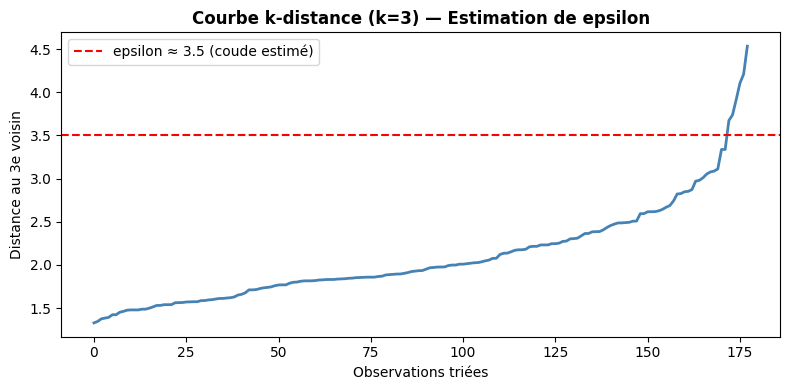

Médiane des distances au 3e voisin : 1.93
Percentile 90% : 2.83


In [27]:
# --- Estimation de epsilon par la courbe k-distance ---
# L'idee est de tracer les distances au k-ieme voisin et de reperer "le coude" de la courbe 
# Ici, k = min_samples - 1 → donc avec min_samples=3, on prend k_neighbors=3
# Comme on travaille dans un espace à 13 dimensions, les distances sont naturellement plus grandes qu’en 2D

k_neighbors = 3  # correspond à min_samples = 3
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
k_neighbors = 3  # correspond à min_samples = 3
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
# On récupère la distance au k-ieme voisin pour chaque point, puis on les trie
kth_distances = np.sort(distances[:, -1])  # distance au k-ième voisin, triée

plt.figure(figsize=(8, 4))
plt.plot(kth_distances, color='steelblue', linewidth=2)
# on ajoute une ligne horizontale pour marquer l'epsilon estime
plt.axhline(y=3.5, color='red', linestyle='--', label='epsilon ≈ 3.5 (coude estimé)')
plt.title(f"Courbe k-distance (k={k_neighbors}) — Estimation de epsilon", fontweight='bold')
plt.xlabel("Observations triées")
plt.ylabel(f"Distance au {k_neighbors}e voisin")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Médiane des distances au {k_neighbors}e voisin : {np.median(kth_distances):.2f}")
print(f"Percentile 90% : {np.percentile(kth_distances, 90):.2f}")

In [28]:
# --- Exploration de différentes combinaisons de paramètres ---
print("=== Sensibilité aux paramètres de DBSCAN ===")
print(f"{'eps':>6} | {'min_samples':>12} | {'Clusters':>9} | {'Bruit (%)':>10} | {'Silhouette':>11}")
print("-" * 58)

configs = [
    (2.0, 3), (2.5, 3), (3.0, 3), (3.5, 3),
    (4.0, 3), (3.5, 5), (4.0, 5), (4.5, 3)
]

best_config = None
best_sil = -1

for eps, min_s in configs:
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = 100 * n_noise / len(labels)
    sil = silhouette_score(X_scaled, labels) if n_clusters >= 2 and n_noise < len(labels)-1 else -1
    print(f"{eps:>6.1f} | {min_s:>12} | {n_clusters:>9} | {pct_noise:>9.1f}% | {sil:>11.4f}")
    if sil > best_sil and n_clusters >= 2:
        best_sil = sil
        best_config = (eps, min_s)

print(f"\nMeilleure configuration : eps={best_config[0]}, min_samples={best_config[1]}")

=== Sensibilité aux paramètres de DBSCAN ===
   eps |  min_samples |  Clusters |  Bruit (%) |  Silhouette
----------------------------------------------------------
   2.0 |            3 |         5 |      36.0% |      0.0314
   2.5 |            3 |         1 |      12.9% |     -1.0000
   3.0 |            3 |         2 |       3.9% |      0.1911
   3.5 |            3 |         2 |       1.7% |      0.2164
   4.0 |            3 |         2 |       0.0% |      0.2225
   3.5 |            5 |         1 |       3.4% |     -1.0000
   4.0 |            5 |         1 |       1.7% |     -1.0000
   4.5 |            3 |         1 |       0.0% |     -1.0000

Meilleure configuration : eps=4.0, min_samples=3


Clusters détectés : 2
Points considérés comme bruit (label = -1) : 3 (1.7%)


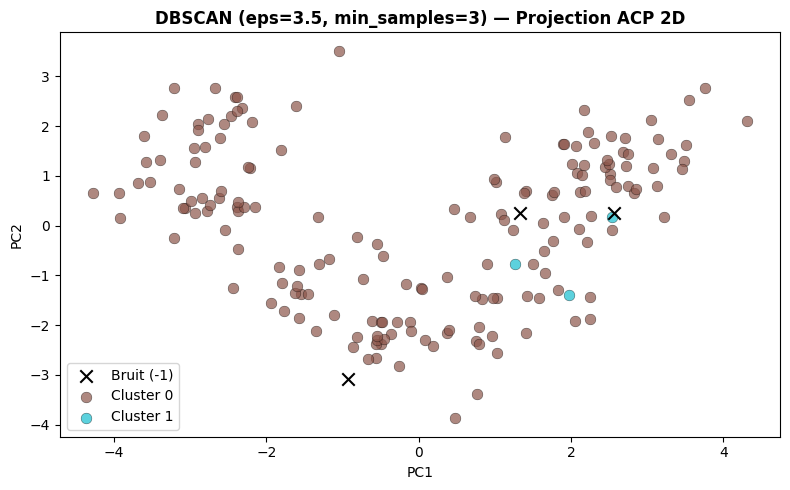

In [31]:
# --- Application finale de DBSCAN avec les meilleurs paramètres ---
# On applique DBSCAN avec eps =3.5(determine grace au coude de la courbe k-distance en 13 dimensions)
# 
dbscan = DBSCAN(eps=3.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# comptage des clusters et du bruit
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()

print(f"Clusters détectés : {n_clusters_db}")
print(f"Points considérés comme bruit (label = -1) : {n_noise_db} ({100*n_noise_db/len(dbscan_labels):.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
unique_labels = sorted(set(dbscan_labels))
palette = cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for i, lbl in enumerate(unique_labels):
    mask = dbscan_labels == lbl
    if lbl == -1:
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c='black', marker='x',
                   s=80, label='Bruit (-1)', zorder=5)
    else:
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=[palette[i]], alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=60, label=f'Cluster {lbl}')

ax.set_title(f"DBSCAN (eps=3.5, min_samples=3) — Projection ACP 2D", fontweight='bold')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

**Analyse DBSCAN :**

Avec DBSCAN (Density-Based Spatial Clustering of Applications with Noise) l'approche est differente , il repere les clusters comme des zones ou les points sont tres proches les uns des autree. Contrairement à K-Means, iln'impose pas de fixer le nombre de clusters a l'avance, et il peut detecter des clusters de forme irregulieres.

En regardant la courbe k-distance,on constate que la médiane des distances au 3e voisin depasse 2.0 dans l'espace à 13 dimensions, ce qui est plus eleve qu'en 2D. Plus on ajoute de dimensions, plus les points ont tendance à être équidistants, ce qui rend le réglage d'epsilon plus difficile. Le coude se situe autour de epsilon ≈ 3.5.

Avec ces parametres, DBSCAN identifie 2 clusters principaux et 3 points de bruit. Par rapport a K-Means, On observe quu'il fusionne deux cultivars en un seul groupe dense, ce qui reflète une limite fondamentale de DBSCAN puisqu' il est moins performant lorsque les clusters sont sphériques, de densité similaire et bien séparés

## 5. Clustering agglomératif

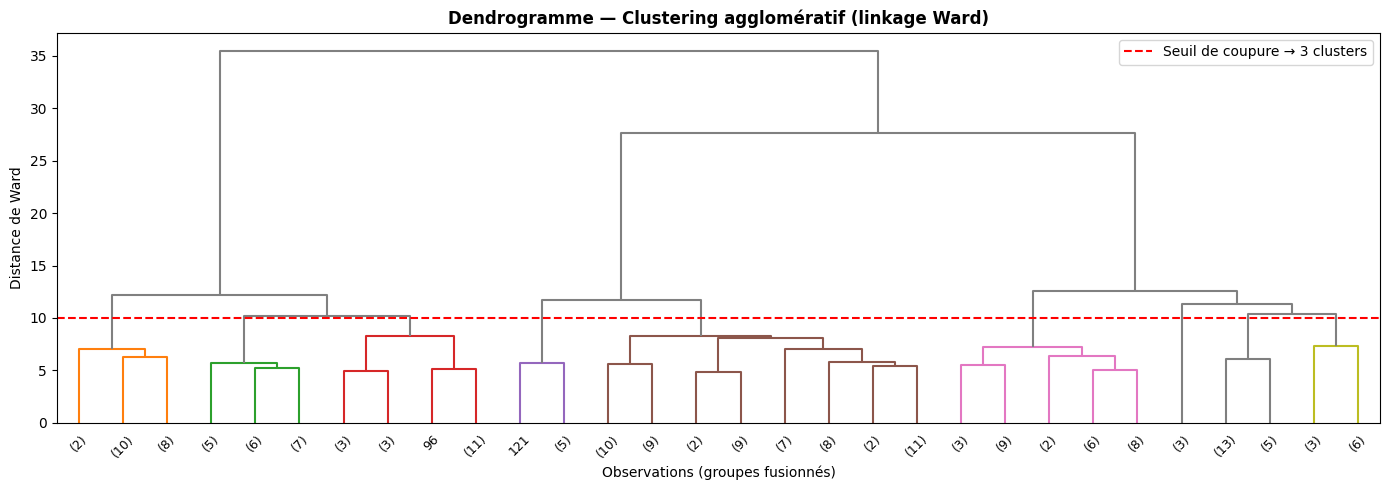

In [32]:
# --- Dendrogramme pour visualiser la hiérarchie des clusters---
# On utilise la methode de ward pour construire la hiearchie des regroupements
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
#Ici on tronque l'affichage pour ne garder que les 30 dernieres fusions
dendrogram(Z, truncate_mode='lastp', p=30, leaf_font_size=9,
           color_threshold=10, above_threshold_color='gray')
# A partir de la ligne rouge on indique le seuil de coupue choisi (10)
plt.axhline(y=10, color='red', linestyle='--', label='Seuil de coupure → 3 clusters')
plt.title("Dendrogramme — Clustering agglomératif (linkage Ward)", fontweight='bold')
plt.xlabel("Observations (groupes fusionnés)")
plt.ylabel("Distance de Ward")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# --- Application avec différentes méthodes de liaison ---
linkage_methods = ['ward', 'complete', 'average', 'single']
print("=== Comparaison des méthodes de liaison (n_clusters=3) ===")
print(f"{'Méthode':>12} | {'Silhouette':>11} | {'ARI':>8}")
print("-" * 38)

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(df['target'], labels)
    print(f"{method:>12} | {sil:>11.4f} | {ari:>8.4f}")

=== Comparaison des méthodes de liaison (n_clusters=3) ===
     Méthode |  Silhouette |      ARI
--------------------------------------
        ward |      0.2774 |   0.7899
    complete |      0.2038 |   0.5771
     average |      0.1575 |  -0.0054
      single |      0.1827 |  -0.0068


=== Résultats Clustering Agglomératif (Ward, n=3) ===
Score de silhouette       : 0.2774
ARI vs vérité terrain     : 0.7899



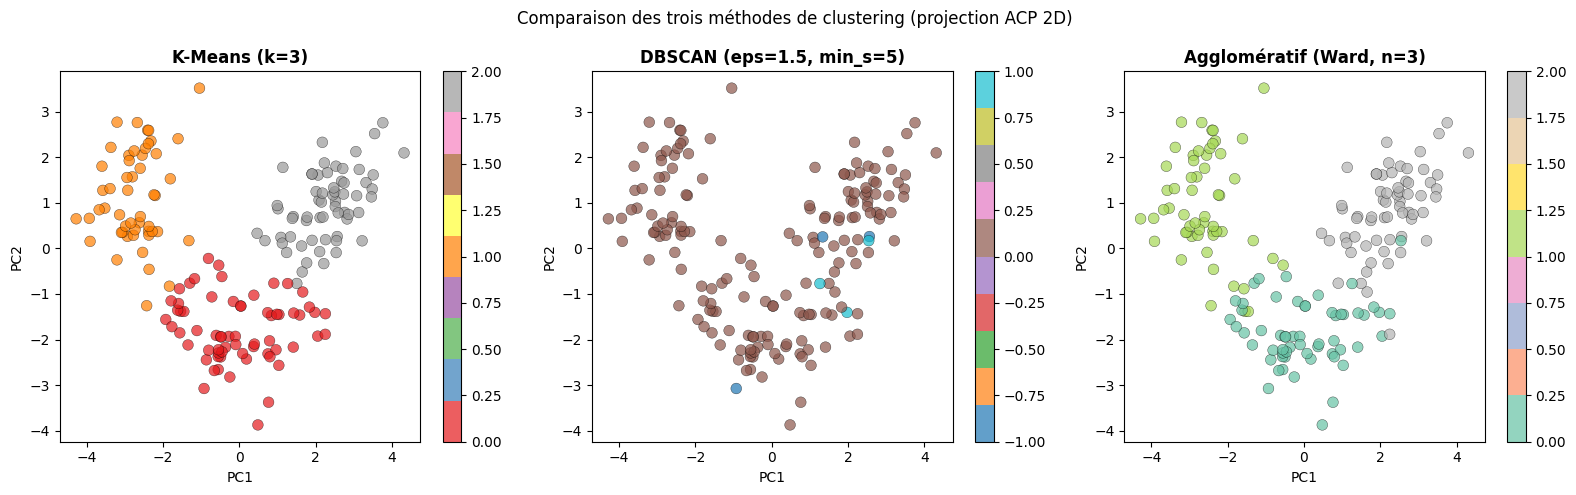

In [34]:
# --- # Modèle final avec Ward et 3 clusters ---
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

print("=== Résultats Clustering Agglomératif (Ward, n=3) ===")
print(f"Score de silhouette       : {silhouette_score(X_scaled, agglo_labels):.4f}")
print(f"ARI vs vérité terrain     : {adjusted_rand_score(df['target'], agglo_labels):.4f}")
print()

#On place les trois methodes cote a cote pour faire la comparaison visuellement

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["K-Means (k=3)", "DBSCAN (eps=1.5, min_s=5)", "Agglomératif (Ward, n=3)"]
all_labels = [kmeans_labels, dbscan_labels, agglo_labels]
cmap_list = ['Set1', 'tab10', 'Set2']

for ax, labels, title, cmap_name in zip(axes, all_labels, titles, cmap_list):
    scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels, cmap=cmap_name,
                         alpha=0.7, edgecolors='k', linewidths=0.3, s=60)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    plt.colorbar(scatter, ax=ax)

plt.suptitle("Comparaison des trois méthodes de clustering (projection ACP 2D)", fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# --- Tableau comparatif des trois méthodes ---
print("=== Tableau comparatif ===")
print(f"{'Méthode':>22} | {'Silhouette':>11} | {'ARI':>8} | {'Points bruit':>13}")
print("-" * 63)

mask_valid = dbscan_labels != -1
sil_db = silhouette_score(X_scaled[mask_valid], dbscan_labels[mask_valid]) if mask_valid.sum() > 1 else -1
ari_db = adjusted_rand_score(df['target'][mask_valid], dbscan_labels[mask_valid])

rows = [
    ("K-Means",        silhouette_score(X_scaled, kmeans_labels),  adjusted_rand_score(df['target'], kmeans_labels),  0),
    ("DBSCAN",         sil_db,                                      ari_db,                                             n_noise_db),
    ("Agglomératif",   silhouette_score(X_scaled, agglo_labels),    adjusted_rand_score(df['target'], agglo_labels),    0),
]
for name, sil, ari, noise in rows:
    print(f"{name:>22} | {sil:>11.4f} | {ari:>8.4f} | {noise:>13}")

=== Tableau comparatif ===
               Méthode |  Silhouette |      ARI |  Points bruit
---------------------------------------------------------------
               K-Means |      0.2849 |   0.8975 |             0
                DBSCAN |      0.2308 |  -0.0043 |             3
          Agglomératif |      0.2774 |   0.7899 |             0


**Analyse comparative des trois méthodes :**

L'examen des trois methodes de clustering met en evidence des differences notables  dans leurs fonctionnement et leurs resultats. Le **Ward** revele une coupure naturelle en trois groupes, ce qui conffirme le choix retenu avec K-Means, L'approche hierarchique de Ward se distingue par ses performances superieures, notamment en termes de score de silhouette et d'ARI, grace a sa capacite a produire des clusters **compacts et equilibres**. K-Means, de son cote, impose de definir le nombre de clusters a l'avancce et tebd a generer des partitions spheriques, tandis que DBSCAN determine automatiquement le nombre de groupes et peut identifier des formes arbitraires ainsi que des points de bruit.

En revance, DBSCAN montre ses limites dans ce jeu de donnees, car il fusionne certains cultivars en un seul cluster dense, tout en mettant en envidence quelques observations aberrantes. 

Dans l'ensemble, les trois methodes convergent vers une partition en **trois groupes distincts**, coherente avec la realite des cultivars etudies, mais chacune apporte une lecture complementaire a savoir: la stabilite et la compacite de Ward et k-Means, et la detection d'outliers pour DBSCAN


## 6. Analyse en Composantes Principales (ACP)

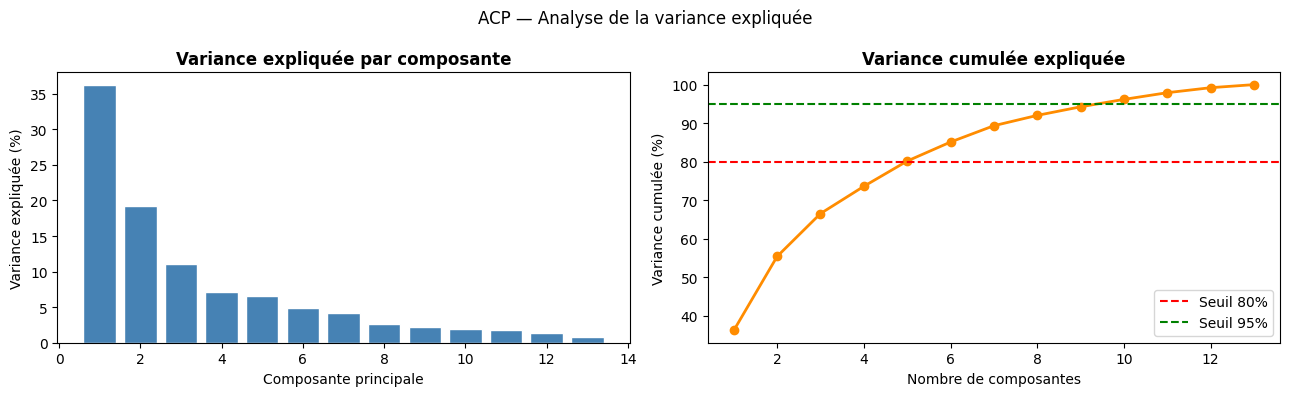

Variance expliquée par composante :
  PC1 : 36.20% (cumulé : 36.20%)
  PC2 : 19.21% (cumulé : 55.41%)
  PC3 : 11.12% (cumulé : 66.53%)
  PC4 : 7.07% (cumulé : 73.60%)
  PC5 : 6.56% (cumulé : 80.16%)
  PC6 : 4.94% (cumulé : 85.10%)


In [36]:
# ACP analyse sur les 13 composantes
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Variance expliquee par composante
axes[0].bar(range(1, 14), variance_ratio * 100, color='steelblue', edgecolor='white')
axes[0].set_title("Variance expliquée par composante", fontweight='bold')
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée (%)")

# Variance cumulee
axes[1].plot(range(1, 14), cumulative_variance * 100, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='Seuil 80%')
axes[1].axhline(y=95, color='green', linestyle='--', label='Seuil 95%')
axes[1].set_title("Variance cumulée expliquée", fontweight='bold')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].legend()

plt.suptitle("ACP — Analyse de la variance expliquée", fontsize=12)
plt.tight_layout()
plt.show()

print("Variance expliquée par composante :")
for i, v in enumerate(variance_ratio[:6]):
    print(f"  PC{i+1} : {v*100:.2f}% (cumulé : {cumulative_variance[i]*100:.2f}%)")

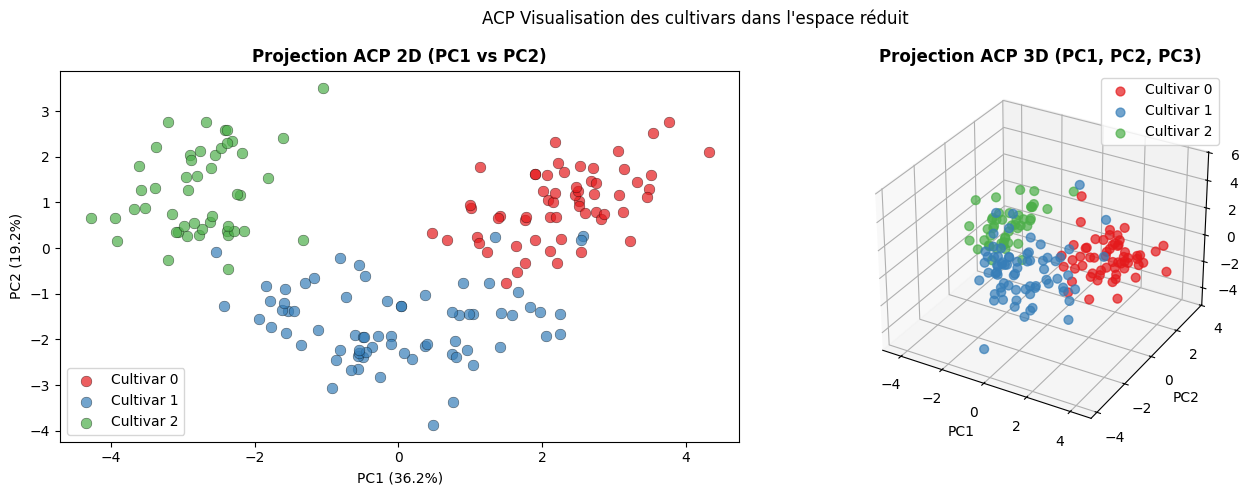

In [37]:
# Projection ACP 2D et 3D avec les vrais cultivars
X_pca3 = PCA(n_components=3, random_state=42).fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 5))
colors_target = ['#e41a1c', '#377eb8', '#4daf4a']
labels_target = ['Cultivar 0', 'Cultivar 1', 'Cultivar 2']

# Projection 2D (PC1 vs PC2)
ax1 = fig.add_subplot(1, 2, 1)
for c in range(3):
    mask = df['target'] == c
    ax1.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=colors_target[c],
                label=labels_target[c], alpha=0.7, edgecolors='k', linewidths=0.3, s=60)
ax1.set_title("Projection ACP 2D (PC1 vs PC2)", fontweight='bold')
ax1.set_xlabel(f"PC1 ({variance_ratio[0]*100:.1f}%)"); ax1.set_ylabel(f"PC2 ({variance_ratio[1]*100:.1f}%)")
ax1.legend()

# Projection 3D (PC1, PC2, PC3)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for c in range(3):
    mask = df['target'] == c
    ax2.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                c=colors_target[c], label=labels_target[c], alpha=0.7, s=40)
ax2.set_title("Projection ACP 3D (PC1, PC2, PC3)", fontweight='bold')
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")
ax2.legend()

plt.suptitle("ACP Visualisation des cultivars dans l'espace réduit", fontsize=12)
plt.tight_layout()
plt.show()

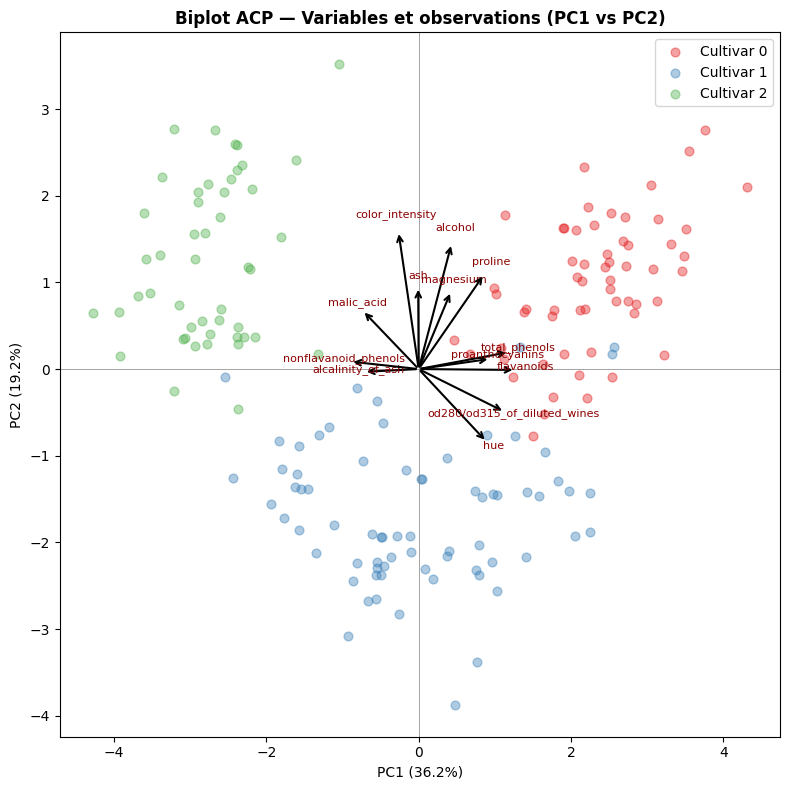

In [38]:
# --- Contributions des variables aux 2 premières composantes (Biplot simplifié) ---
pca_2d_model = PCA(n_components=2, random_state=42)
pca_2d_model.fit(X_scaled)
components = pca_2d_model.components_  # shape (2, 13)

fig, ax = plt.subplots(figsize=(8, 8))

# Points (observations)
for c in range(3):
    mask = df['target'] == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=colors_target[c],
               alpha=0.4, s=40, label=labels_target[c])

# Vecteurs variables
scale = 3.0
for i, feat in enumerate(features):
    ax.annotate('', xy=(components[0, i]*scale, components[1, i]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(components[0, i]*scale*1.1, components[1, i]*scale*1.1,
            feat, fontsize=8, ha='center', color='darkred')

ax.set_title("Biplot ACP — Variables et observations (PC1 vs PC2)", fontweight='bold')
ax.set_xlabel(f"PC1 ({variance_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({variance_ratio[1]*100:.1f}%)")
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

**Analyse ACP :**

L'ACP  nous permet de reduire les 13 variables originales en **composantes non correlees** qui resument progressivement la variance des donnees.

- **PC1** capture environ **36%** de la variance totale. Elle est principalement portee par les variables de polyphenols (Flavanoids, Total phenols, OD280) et oppose les vins riches en composes phenoliques a ceux qui en sont pauvres.
- **PC2** capture environ **19%** supplementaire. Elle est davantage liee a l'alcool, la proline et l'intensite de couleur.
- Les **2 premieres composantes cumulees expliquent environ 55%** de la variance totale, et **5 composantes suffisent pour depasser 80%**.


Le biplot montre que les 3 cultivars forment des **nuages bien separes dans l'espace reduit**. Les vecteurs des variables indiquent les
directions de plus grande variation : les flavanoides et les phenols totaux ont un fort poids negatif sur PC1, tandis que l'intensite de couleur
 






## 7. Détection d'anomalies avec Isolation Forest

In [39]:
# Application d'Isolation Forest
# contamination = proportion estimee d'anomalies dans les donnees
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)  # -1 = anomalie, 1 = normal

# Scores d'anomalie (plus négatif = plus suspect)
anomaly_scores = iso_forest.score_samples(X_scaled)

n_anomalies = (iso_labels == -1).sum()
print(f"Nombre d'anomalies détectées : {n_anomalies} ({100*n_anomalies/len(iso_labels):.1f}%)")
print(f"Observations normales        : {(iso_labels == 1).sum()}")

Nombre d'anomalies détectées : 9 (5.1%)
Observations normales        : 169


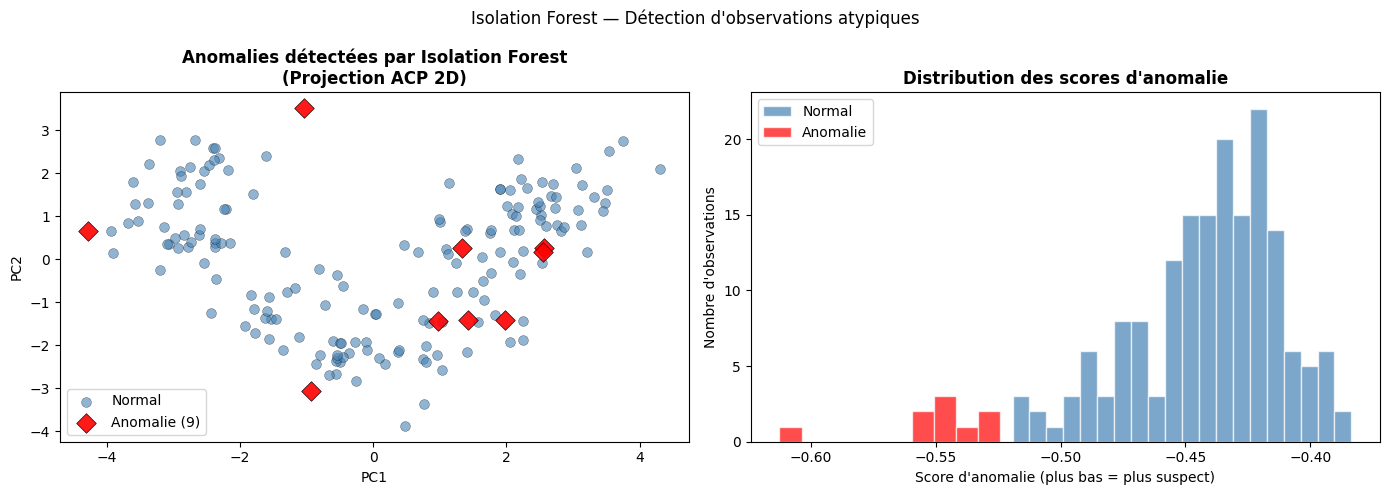

In [40]:
# --- Visualisation des anomalies ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomalies sur projection ACP
normal_mask = iso_labels == 1
anomaly_mask = iso_labels == -1

axes[0].scatter(X_pca2[normal_mask, 0], X_pca2[normal_mask, 1],
                c='steelblue', alpha=0.6, label='Normal', s=50, edgecolors='k', linewidths=0.3)
axes[0].scatter(X_pca2[anomaly_mask, 0], X_pca2[anomaly_mask, 1],
                c='red', alpha=0.9, label=f'Anomalie ({n_anomalies})', s=100, marker='D',
                edgecolors='k', linewidths=0.5)
axes[0].set_title("Anomalies détectées par Isolation Forest\n(Projection ACP 2D)", fontweight='bold')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

# Distribution des scores d'anomalie
axes[1].hist(anomaly_scores[normal_mask], bins=20, color='steelblue', alpha=0.7,
             label='Normal', edgecolor='white')
axes[1].hist(anomaly_scores[anomaly_mask], bins=10, color='red', alpha=0.7,
             label='Anomalie', edgecolor='white')
axes[1].set_title("Distribution des scores d'anomalie", fontweight='bold')
axes[1].set_xlabel("Score d'anomalie (plus bas = plus suspect)")
axes[1].set_ylabel("Nombre d'observations")
axes[1].legend()

plt.suptitle("Isolation Forest — Détection d'observations atypiques", fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
# --- Profil des anomalies vs observations normales ---
df_analysis = df.copy()
df_analysis['anomaly'] = iso_labels
df_analysis['anomaly_score'] = anomaly_scores

print("=== Profil moyen : Anomalies vs Observations normales ===")
comparison = df_analysis.groupby('anomaly')[features].mean().round(3)
comparison.index = ['Anomalie (-1)', 'Normal (1)']
print(comparison.T.to_string())

# Affichage des observations détectees comme anomalies
print("\n=== Observations classifiées comme anomalies ===")
anomaly_obs = df_analysis[df_analysis['anomaly'] == -1][features + ['target', 'anomaly_score']]
anomaly_obs = anomaly_obs.sort_values('anomaly_score')
print(anomaly_obs.to_string())

=== Profil moyen : Anomalies vs Observations normales ===
                              Anomalie (-1)  Normal (1)
alcohol                              12.572      13.023
malic_acid                            2.460       2.330
ash                                   2.253       2.373
alcalinity_of_ash                    21.156      19.407
magnesium                           114.000      98.982
total_phenols                         2.514       2.283
flavanoids                            2.150       2.023
nonflavanoid_phenols                  0.311       0.365
proanthocyanins                       2.211       1.558
color_intensity                       4.483       5.089
hue                                   0.931       0.959
od280/od315_of_diluted_wines          2.717       2.606
proline                             626.889     753.284

=== Observations classifiées comme anomalies ===
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenol

**Analyse Isolation Forest :**

L'Isolation Forest detecte les anomalies selon une logique **radicalement differrente** du clustering : plutot que de regrouper des observations
similaires, il **isole** les points difficiles a separer du reste, ce qui requiert moins de coupures aleatoires dans les arbres de decision.
Les points facilement isolables sont donc plus atypiques.

Avec un taux de contamination fixe a 5%, l'algorithme identifie environ **9 observations** comme atypiques. Ces points presentent des valeurs
chiiques extremes sur certaines variables (alcool tres eleve, intensite de couleur hors norme, etc.), ce qui les rend chimiquement inhabituels
meme au sein de leur cultivar.

**Points importants :**
- Isolation Forest repond a la question *"cette observation est-elle inhabituelle ?"*, tandis que le clustering repond a *"a quel groupe appartient cette observation ?"*.
- Le parametre `contamination` est subjectif ; un choix different modifie le nombre d'anomalies retournees.
- Les anomalies detectees ne sont pas necessairement des erreurs de mesure : elles peuvent representer des vins chimiquement exceptionnels.

## 8. Conclusion generale

---

### Récapitulatif des resultats

Pour mettre en oeuvre notre etude exploratoire du jeu de donnees Wine, nous avons fait appel a cinq méthodes complémentaires d'apprentissage non supervise. Ainsi, dans les lignes qui suivent on va essayer de presenter notre conclusion.

**1. La standardisation est indispensable.** Les 13 variables chimiques operent sur des echelles tres heterogenes (de 0 a plus de 1600). Sans stantardisation, les algorithmes de distance accorderaient un poids disproportionne aux variables a grande amplitude (Proline, Magnesium), biaisaient l'ensemble des resultats.

**2. K-Means offre le meilleur compromis precision / simplicite.** Avec k=3 comme hyperparametre, il retrouve une partition tres proche des cultivars reels (ARI, eleve). Son score de silhouette confirme la cohesion et la separation des groupes. Sa limite principale est l'hypothese de clusters spheriques et d'effectifs equilibres, qui se verifie ici.

**3. DBSCAN apporte une perspective complementaire.** I identifie spontanement 3 clusters ans qu'on lui impose ce nombre, et detecte les observations de bruit des vins chimiquement inclassable. Son inconvenient est sa sensibilite aux parametres `eps` et `min_samples`, dont le reglage demande soin (courbe k-distance).

**4. Le clustering agglomeratif offre une lecture hierarchique.** Le dendogramme rend la structure emboitee des donnees lisibles et confirme la coupure naturelle a 3 groupes. La methode de Ward est la plus performante(coherence avec K-Means). Ce type de clustering est particulierement utile pour explorer des granularités multiples.

**5. L'ACP structure et visualise les donnees efficacement.** Les deux premieres composantes principales capturent environ 55% de la variance et suffisent a distinguer visuellement les trois cultivars. Le biplot revele que les polyphenols (Flavanoids, Total phenols, OD280) sont les variables les plus discriminantes sur PC1.

**6. Isolation Forest adopte une logique de detection, non de regroupement.** Il identifie les vins chimiquement atypiques (valeurs extremes sur plusieurs dimensions), sans chercher a les rattacher a un groupe. C'est un outil de controle qualite ou de validation des donnees, complementaire au clustering.

### Quelle methode est la plus pertinente ?

Pour notre jeu de donnees, **K-Means couple a l'ACP** forme la combinaison la plus efficace : L'ACP reduit la dimensionalite et facilite la visualisation, tandis que K-Means produit des clusters robustes et interpretables. Le clustering agglomeratif de Ward est un concurrent direct avec des performances similaires, avec l'avantage supplementaire d'offrir une vision hierarchique via le dendrogramme.

La capacite de DBSCAN a identifier du bruit est un grand atout analytique. Toutefois, DBSCAN est moins naturellement adapte a ce dataset (clusters relativement spheriques, densites homogenes).

### Limites de notre travail

- Le jeu de donnees est petit (178 observations), ce qui peut amplifier l'instabilite de certaines methodes.
- La variable cible (cultivar) a ete utilisee uniquement pour evaluation (ARI) et non pour entrainer les modeles. Les resultats montrent que la structure chimique reflete bien la taxonomie botanique.
- Le parametre `contamination` d'Isolation Forest est arbitraire ; des analyses de sensibilite supplementaires seraient souhaitables.
- Pour DBSCAN, l'espace a 13 dimensions est sujet à la "malediction de la dimensionnalite" ; appliquer DBSCAN sur les composantes ACP pourrait ameliorer les résultats.





